In [17]:
import torch
from neural_lam import constants
import matplotlib.pyplot as plt
import numpy as np

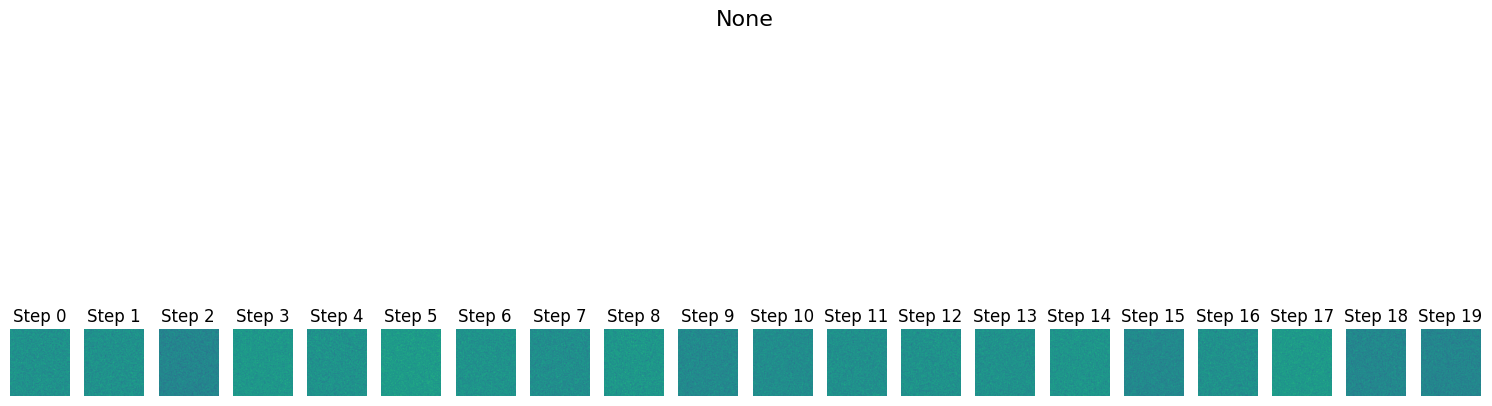

In [18]:
pred_steps = [torch.randn(1, 63784, 1) for _ in range(20)]
pred = torch.randn(1, 63784, 1)
target = torch.randn(1, 63784, 1)

def plot_predictions(pred_steps, pred, target, height=268, width=238, title=None):
    num_steps = len(pred_steps)
    
    # Reshape tensors to (time, height, width, var_dim) for plotting
    pred_steps_reshaped = [p.view(height, width).cpu().numpy()[::-1, ...] for p in pred_steps]
    pred_reshaped = pred.view(height, width).cpu().numpy()[::-1, ...]
    target_reshaped = target.view(height, width).cpu().numpy()[::-1, ...]

    fig, axes = plt.subplots(1, num_steps, figsize=(15, 7))
    
    # Plot each time step in pred_steps on the first row
    for step_idx, step in enumerate(pred_steps_reshaped):
        axes[step_idx].imshow(step, cmap="viridis")
        axes[step_idx].set_title(f"Step {step_idx}")
        axes[step_idx].axis("off")

    # Plot pred and target on the second row
    # axes[1, num_steps // 2 - 1].imshow(pred_reshaped, cmap="viridis")
    # axes[1, num_steps // 2 - 1].set_title("Prediction")
    # axes[1, num_steps // 2 - 1].axis("off")
    
    # axes[1, num_steps // 2].imshow(target_reshaped, cmap="viridis")
    # axes[1, num_steps // 2].set_title("Target")
    # axes[1, num_steps // 2].axis("off")

    # Clear remaining axes on the second row if more than two slots
    # for ax in axes[1, :num_steps]:
    #     if ax not in (axes[1, num_steps // 2 - 1], axes[1, num_steps // 2]):
    #         ax.axis("off")
    
    # Set figure title for the variable
    fig.suptitle(f"{title}", fontsize=16)
    plt.tight_layout()
    plt.show()

# Example usage:
plot_predictions(pred_steps, pred, target)

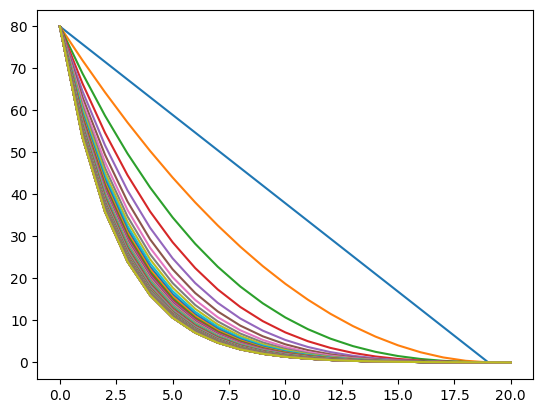

In [26]:
# t_steps = [8.0000e+01, 6.2081e+01, 4.7719e+01, 3.6304e+01, 2.7315e+01, 2.0305e+01,
#         1.4897e+01, 1.0774e+01, 7.6708e+00, 5.3673e+00, 3.6842e+00, 2.4754e+00,
#         1.6238e+00, 1.0368e+00, 6.4192e-01, 3.8368e-01, 2.2015e-01, 1.2040e-01,
#         6.2206e-02, 3.0000e-02, 0.0000e+00]

def round_sigma(sigma):
    return torch.as_tensor(sigma)

num_steps = 20
sigma_max = 80
sigma_min = 0.03
rho = 7
for rho in range(1, 100):
    t_steps = (sigma_max ** (1 / rho) + torch.arange(num_steps, dtype=torch.float32) / (num_steps - 1) * (sigma_min ** (1 / rho) - sigma_max ** (1 / rho))) ** rho
    t_steps = torch.cat([round_sigma(t_steps), torch.zeros_like(t_steps[:1])]) # t_N = 0
    plt.plot(t_steps)
# step_indices = torch.arange(num_steps, dtype=torch.float32)
# t_steps = (sigma_max ** (1 / rho) + step_indices / (num_steps - 1) * (sigma_min ** (1 / rho) - sigma_max ** (1 / rho))) ** rho
# t_steps = torch.cat([round_sigma(t_steps), torch.zeros_like(t_steps[:1])]) # t_N = 0

# plt.plot(t_steps)

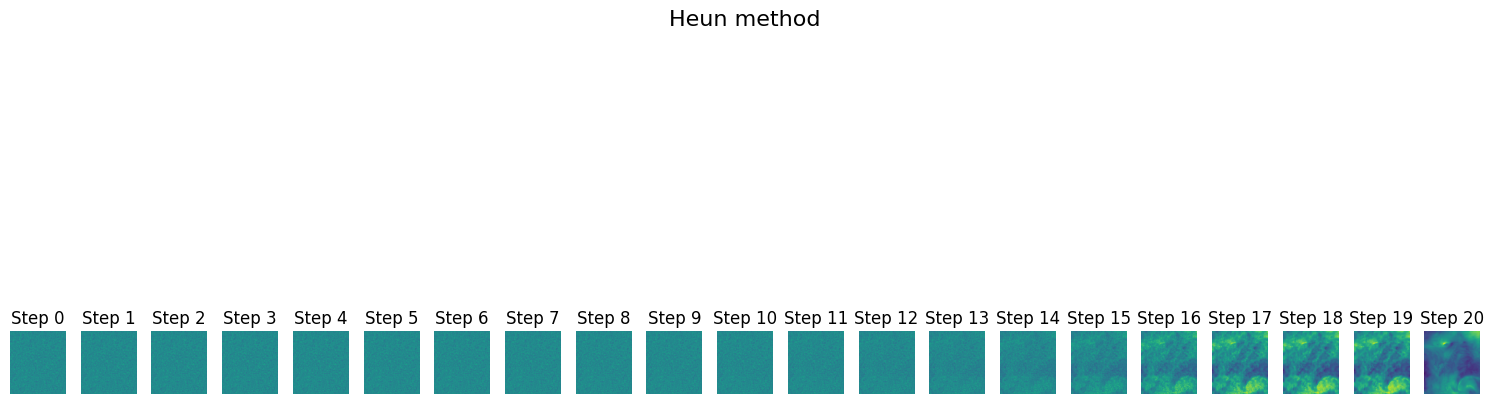

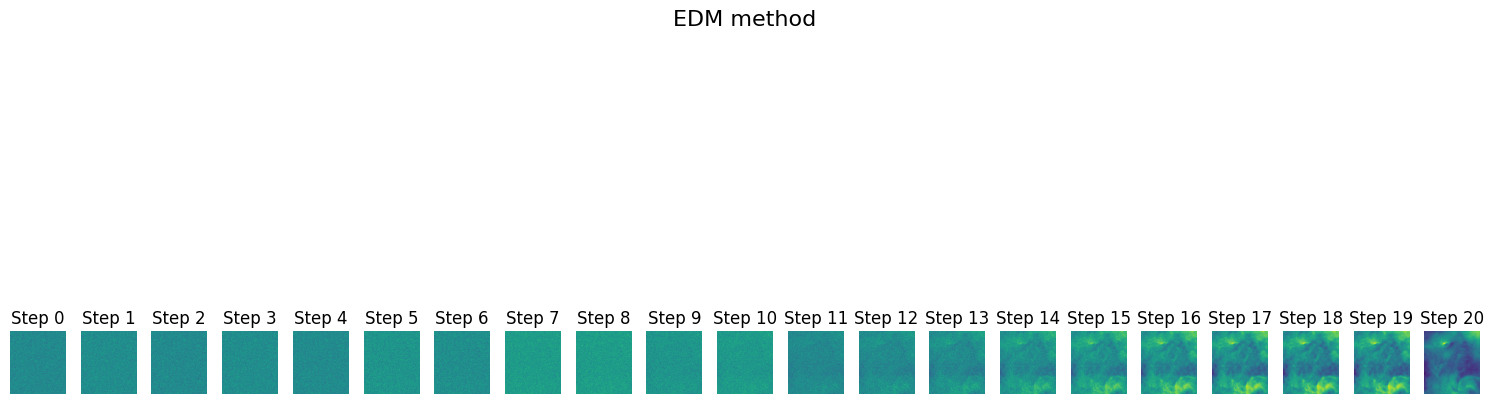

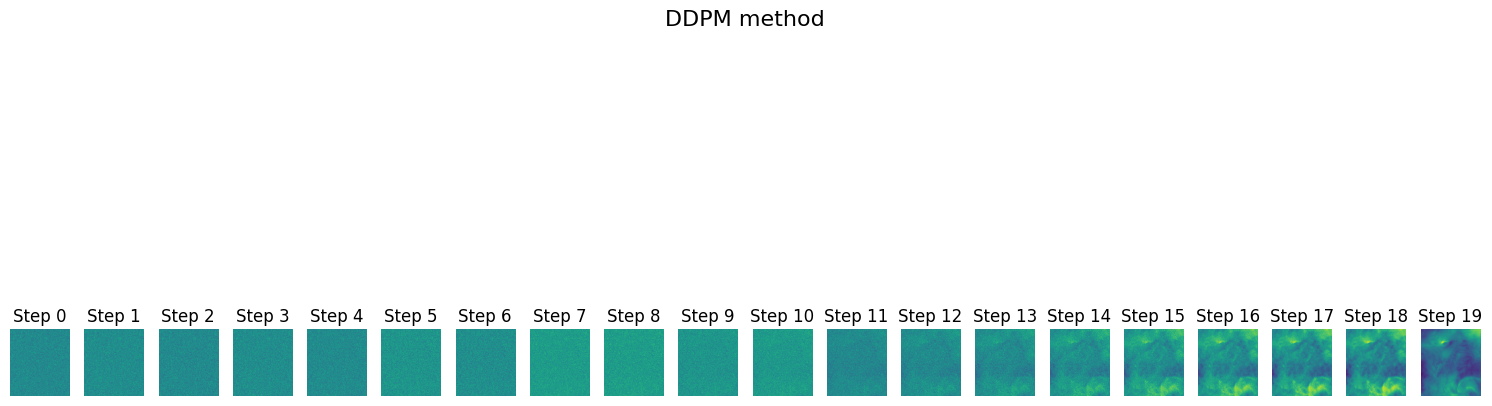

In [20]:
diff_states_heun = np.load("/proj/berzelius-2022-164/users/x_erila/neural-lam/output/diff_states_heun.npy")
next_state_heun = np.load("/proj/berzelius-2022-164/users/x_erila/neural-lam/output/next_state_heun.npy")
true_state_heun = np.load("/proj/berzelius-2022-164/users/x_erila/neural-lam/output/true_state_heun.npy")

diff_states_edm = np.load("/proj/berzelius-2022-164/users/x_erila/neural-lam/output/diff_states_edm.npy")
next_state_edm = np.load("/proj/berzelius-2022-164/users/x_erila/neural-lam/output/next_state_edm.npy")
true_state_edm = np.load("/proj/berzelius-2022-164/users/x_erila/neural-lam/output/true_state_edm.npy")

diff_states_ddpm = np.load("/proj/berzelius-2022-164/users/x_erila/neural-lam/output/diff_states_ddpm.npy")
next_state_ddpm = np.load("/proj/berzelius-2022-164/users/x_erila/neural-lam/output/next_state_ddpm.npy")
true_state_ddpm = np.load("/proj/berzelius-2022-164/users/x_erila/neural-lam/output/true_state_ddpm.npy")

var_dim = 0
plot_predictions(torch.tensor(diff_states_heun[:, :, :, var_dim]), torch.tensor(next_state_heun[:, :, var_dim]), torch.tensor(true_state_heun[:, :, var_dim]), title="Heun method")
plot_predictions(torch.tensor(diff_states_edm[:, :, :, var_dim]), torch.tensor(next_state_edm[:, :, var_dim]), torch.tensor(true_state_edm[:, :, var_dim]), title="EDM method")
plot_predictions(torch.tensor(diff_states_ddpm[:, :, :, var_dim]), torch.tensor(next_state_ddpm[:, :, var_dim]), torch.tensor(true_state_ddpm[:, :, var_dim]), title="DDPM method")



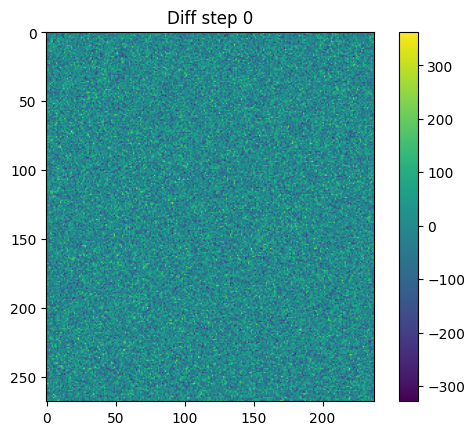

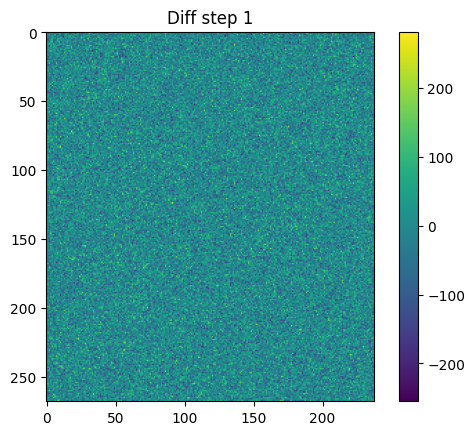

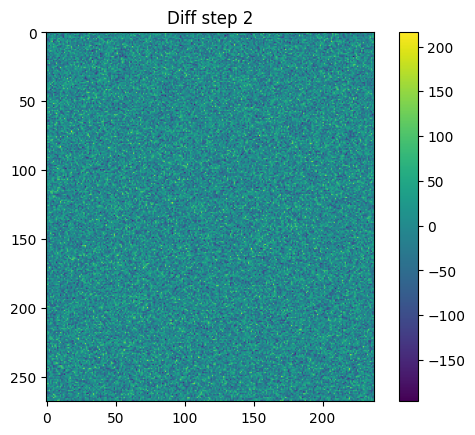

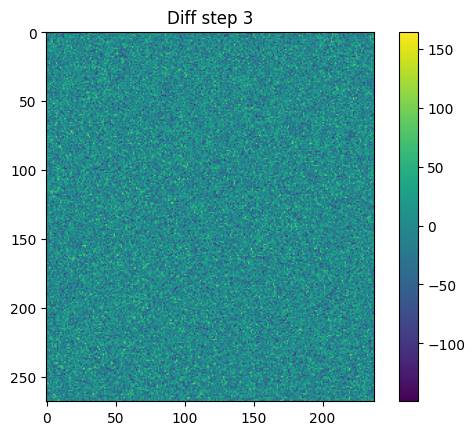

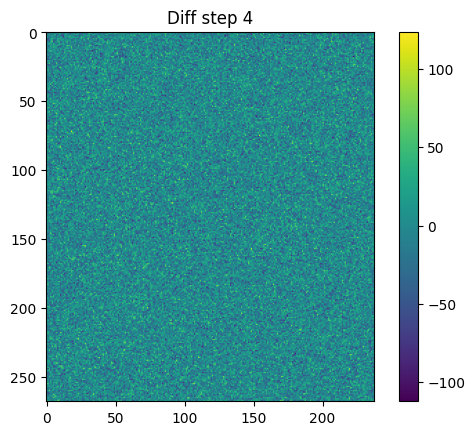

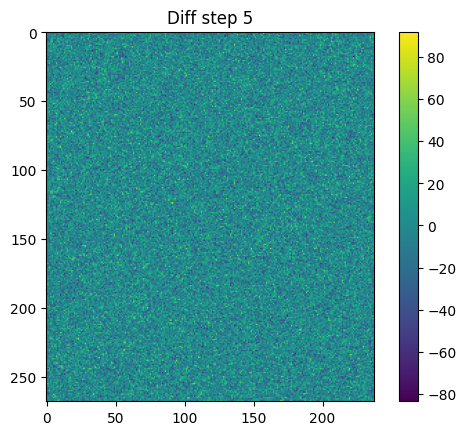

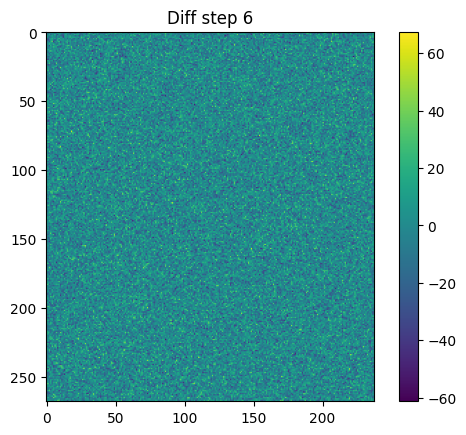

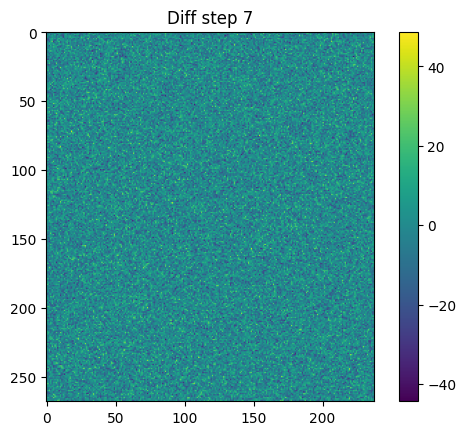

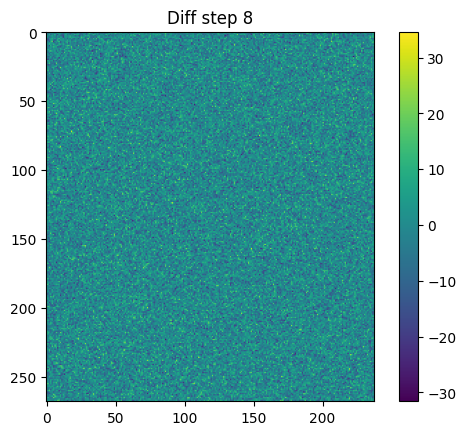

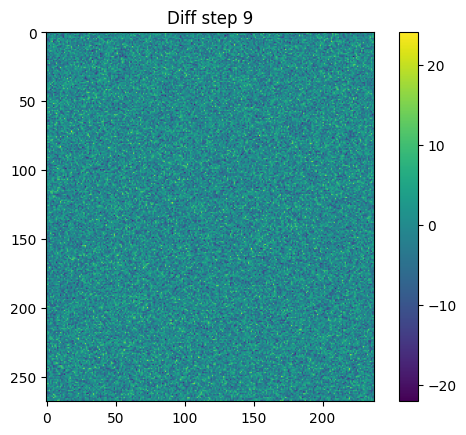

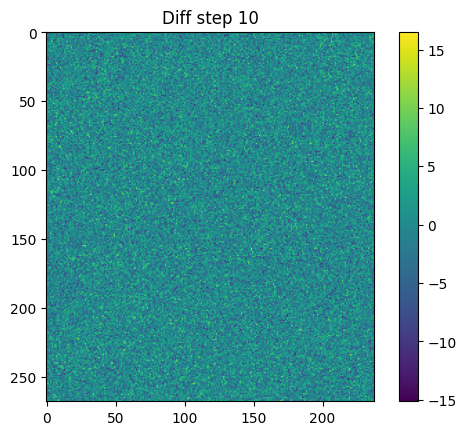

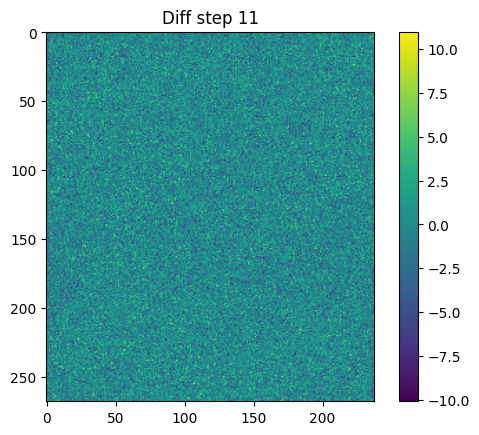

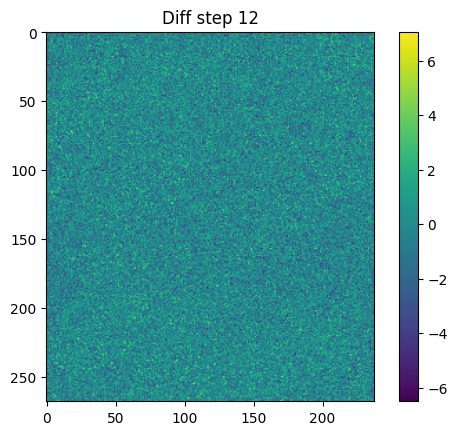

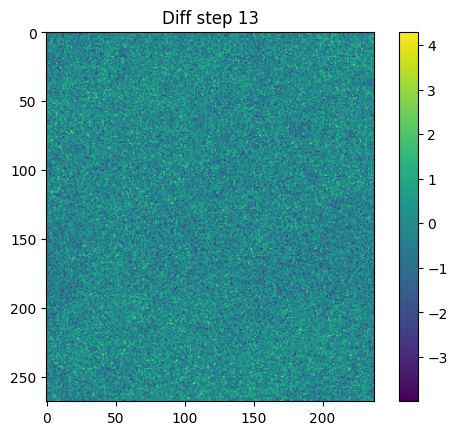

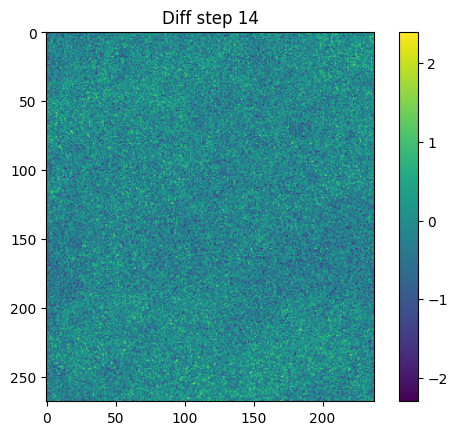

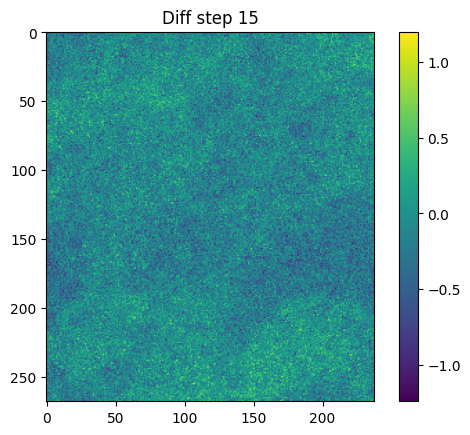

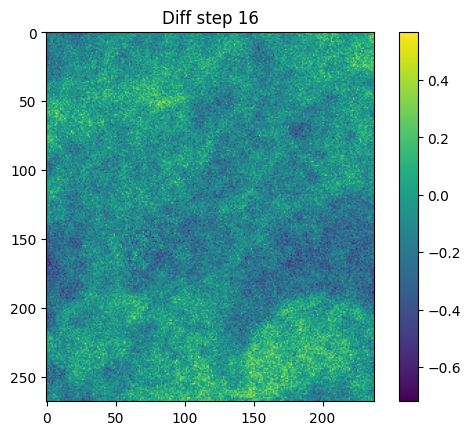

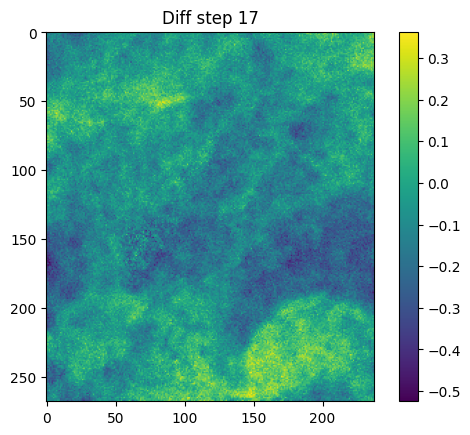

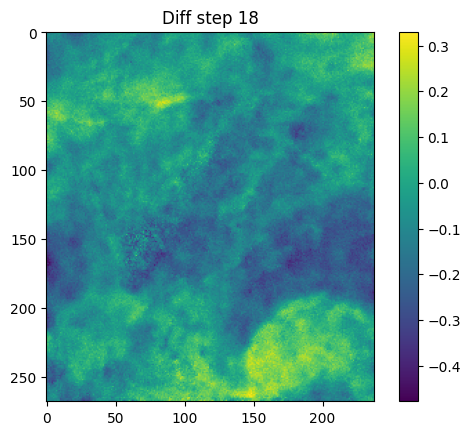

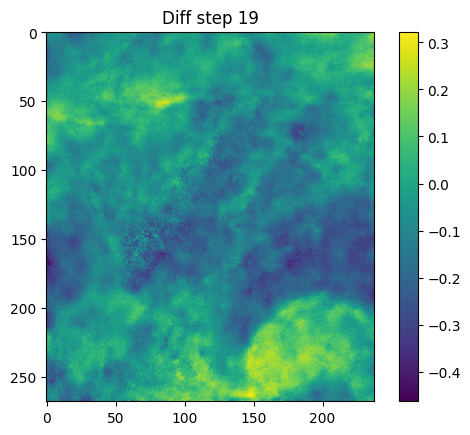

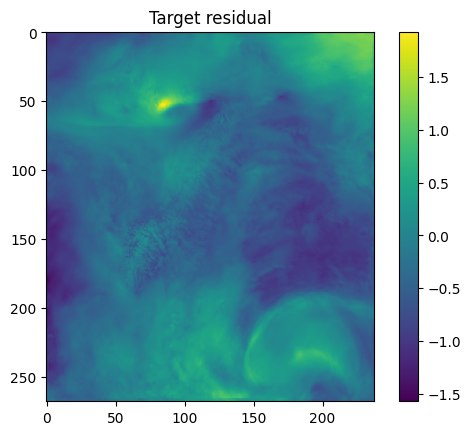

In [21]:
for i, diff_state in enumerate(diff_states_heun):
    plt.imshow(torch.tensor(diff_state[:, :, var_dim]).view(268, 238).cpu().numpy()[::-1, ...])
    plt.colorbar()
    if i < len(diff_states_heun) - 1:
        plt.title(f"Diff step {i}")
    else:
        plt.title("Target residual")
    plt.show()